# Deconvolved Spatial Transcriptomics Data Analysis

In [1]:
# Import 
library(Seurat)
library(grid)
library(ggplot2)
library(viridis)
library(dplyr)
library(patchwork)
set.seed(1)

# Multicore CPU usage activation - Future

library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed=TRUE # Removes future-generated statistical errors

data_dir <- "./deconvolved"

print("Loading 10X Spatial data...")
seurat_obj <- Load10X_Spatial(
  data.dir = data_dir,
)

seurat_obj@project.name <- "Breast Cancer"

seurat_obj

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Loading 10X Spatial data..."


An object of class Seurat 
18031 features across 12240 samples within 1 assay 
Active assay: Spatial (18031 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

[1] "Running QC..."


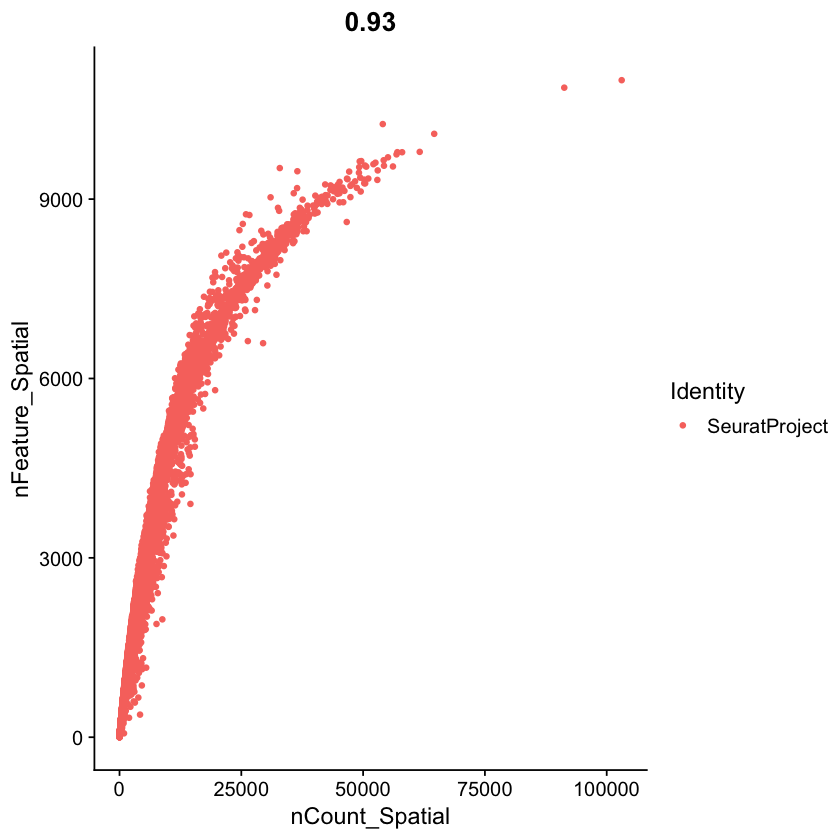

In [2]:
# Quality Control 
print("Running QC...")

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


An object of class Seurat 
18031 features across 12232 samples within 1 assay 
Active assay: Spatial (18031 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

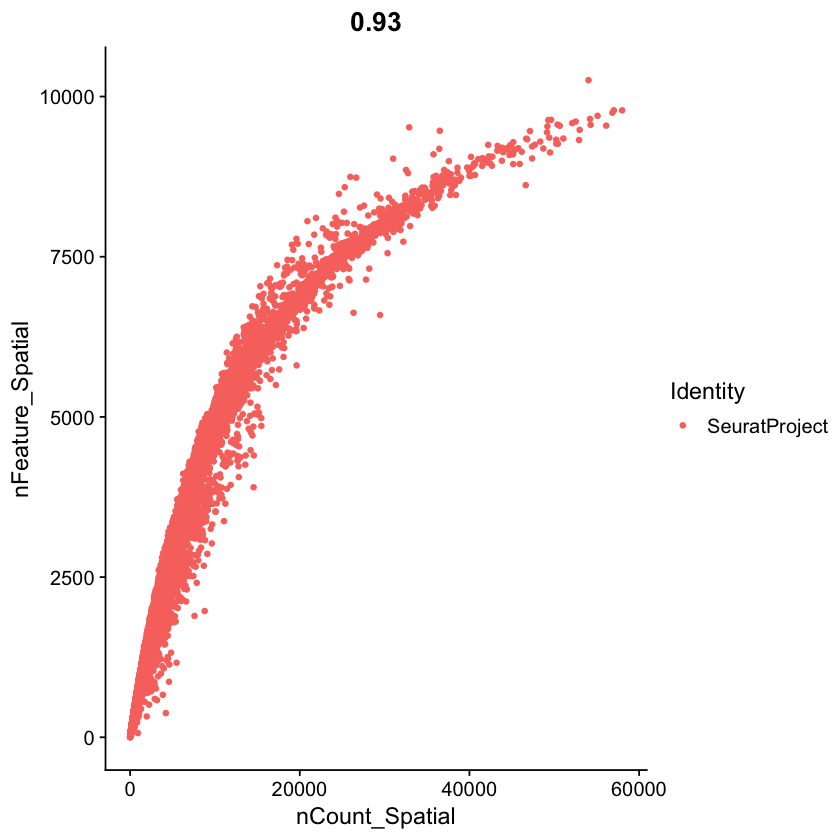

In [3]:
seurat_obj <- subset(seurat_obj, subset = nFeature_Spatial > 0 & nCount_Spatial < 60000)

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

seurat_obj

[1] "Normalizing and Scaling..."


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



[1] "Running PCA..."


PC_ 1 
Positive:  MMP2, C3, CXCL12, RNASE1, COL14A1, F13A1, VCAN, PTGDS, MGP, FBLN1 
	   PLTP, IGKC, EFEMP1, STAB1, HTRA1, COL5A2, SERPINF1, IGHG1, MS4A6A, FBLN2 
	   CD14, CDH11, IGHA1, MFAP4, FN1, TIMP3, JCHAIN, IGF1, FGL2, CTHRC1 
Negative:  ANKRD30A, MLPH, EPCAM, SLC12A2, SCD, MUC1, SREBF1, PPM1D, ELF3, MAL2 
	   PHB, PERP, GRB7, TUBD1, ZNF652, PSMD12, TACO1, KRT8, SPAG16, BAMBI 
	   ALDH3B2, SLC9A3R1, ITPRID2, PSMG1, UGDH, CXCL17, PIP, HMGCS2, NRAS, TOB1 
PC_ 2 
Positive:  TNXB, FABP4, GPX3, CFD, ADH1B, PLIN4, OGN, PLIN1, ADIPOQ, G0S2 
	   HSPB6, LYVE1, LPL, COL14A1, SRPX, PPP1R1A, PLTP, GPD1, DLK1, CHRDL1 
	   ADAM33, EFEMP1, SLC19A3, ALPL, RNASE1, IGF1, PTGIS, MMP3, PENK, ALX4 
Negative:  IL7R, TRAC, TRBC2, CD52, CD2, LCP1, CCL19, TRBC1, LTB, TNFAIP3 
	   RESF1, SELL, IL2RG, CYTIP, ARHGAP15, CXCR4, IKZF1, STK17B, BTG1, TMC8 
	   LYZ, CCL5, CIITA, RIPOR2, ARHGDIB, STK4, IL32, ACAP1, CORO1A, SPOCK2 
PC_ 3 
Positive:  CEACAM6, KRT17, KRT14, KRT23, KRT5, KRT15, KRT6B, KLK5, ITGA3, S

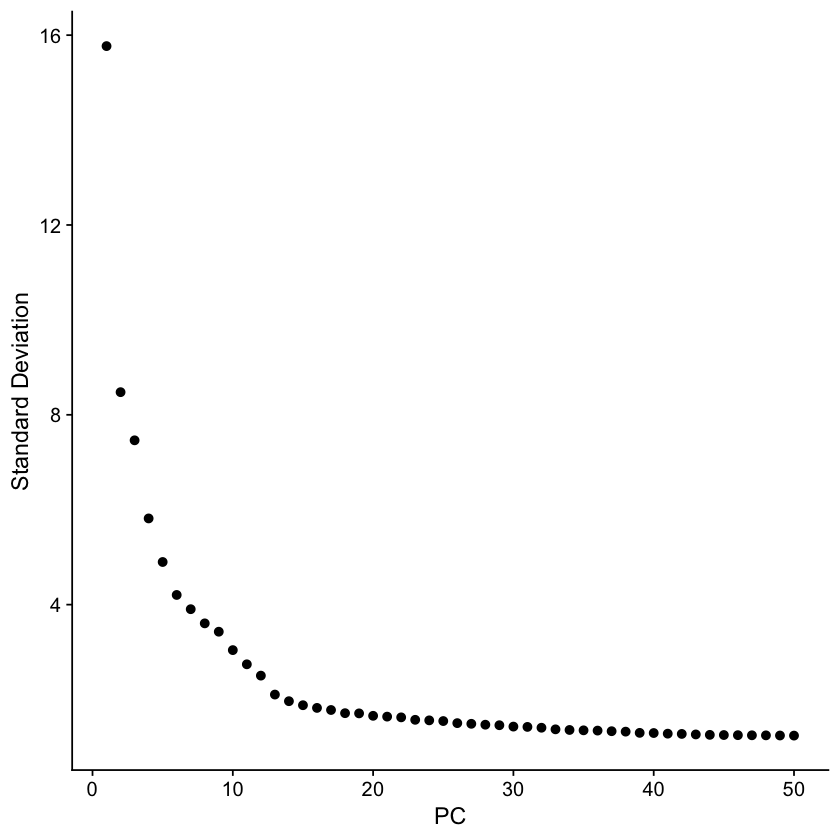

In [4]:
# Normalization & Feature Selection
print("Normalizing and Scaling...")

seurat_obj <- NormalizeData(seurat_obj, normalization.method = "LogNormalize", scale.factor = 10000)
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(seurat_obj)
seurat_obj <- ScaleData(seurat_obj, features = all.genes)

# PCA
print("Running PCA...")

seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))

# Elbow Plot
print(ElbowPlot(seurat_obj, ndims = 50))

In [5]:
# UMAP
dims_use <- 1:29 

print("Running UMAP...")
seurat_obj <- RunUMAP(seurat_obj, dims = dims_use)

[1] "Running UMAP..."


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:12:32 UMAP embedding parameters a = 0.9922 b = 1.112

19:12:32 Read 12232 rows and found 29 numeric columns

19:12:32 Using Annoy for neighbor search, n_neighbors = 30

19:12:32 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:12:33 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//Rtmp5zZ7k4/filef6657b1b67b1

19:12:33 Searching Annoy index using 10 threads, search_k = 3000

19:12:33 Annoy recall = 100%

19:12:33 Commencing smooth kNN distance calib

[1] "Clustering..."


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12232
Number of edges: 453291

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9312
Number of communities: 16
Elapsed time: 1 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


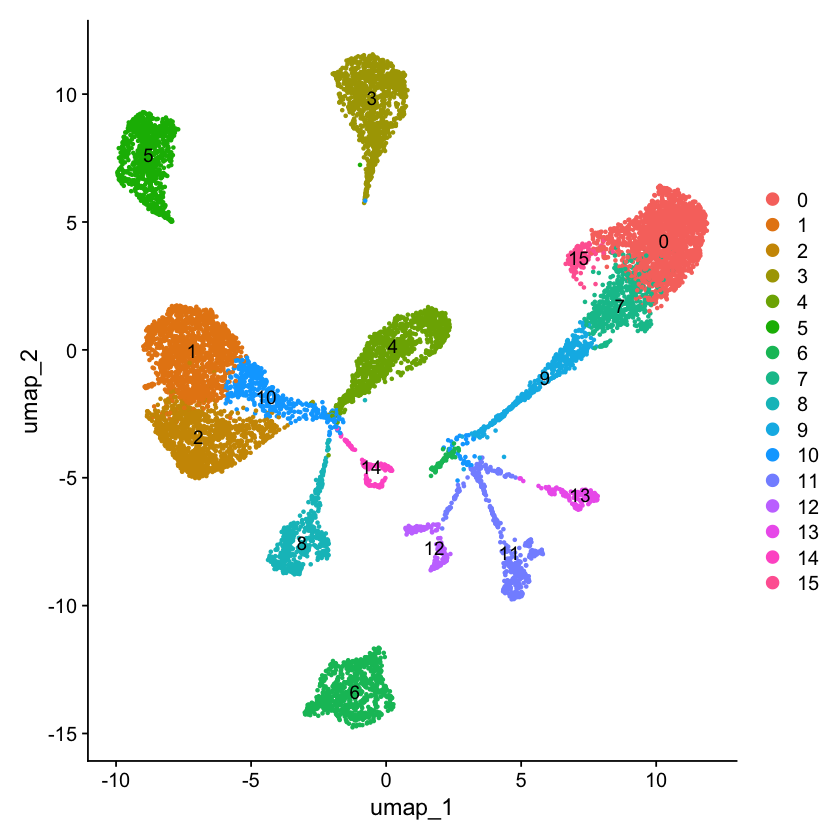

In [143]:
# In Silico Cell Clustering

print("Clustering...")
seurat_obj <- FindNeighbors(seurat_obj, dims = dims_use)
seurat_obj <- FindClusters(seurat_obj, resolution = 0.5) 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5)

In [4]:
all_markers <- FindAllMarkers(
  seurat_obj, 
  only.pos = TRUE,     
  min.pct = 0.5,       
  logfc.threshold = 1 
)

library(dplyr)
all_markers_sorted <- all_markers %>%
  group_by(cluster) %>%
  arrange(cluster, desc(avg_log2FC)) 

write.csv(all_markers_sorted, file = "all_cluster_markers.csv", row.names = FALSE)

print("Markers saved to 'all_cluster_markers.csv'")

top_markers <- all_markers_sorted %>%
    group_by(cluster) %>%
    slice_head(n = 3)

print(top_markers)

Calculating cluster Tumor Edge 

Calculating cluster Tumor Front

Calculating cluster Tumor Core

Calculating cluster Desmoplastic Tumor

Calculating cluster Luminal B

Calculating cluster Luminal A

Calculating cluster CD4 T-cells

Calculating cluster Plasma Cells

Calculating cluster TAMs

Calculating cluster myCAFs

Calculating cluster iCAFs

Calculating cluster Adipocytes

Calculating cluster Endothelial Cells

Calculating cluster Myoepithelial Cells



[1] "Markers saved to 'all_cluster_markers.csv'"
# A tibble: 42 × 7
# Groups:   cluster [14]
       p_val avg_log2FC pct.1 pct.2 p_val_adj cluster              gene  
       <dbl>      <dbl> <dbl> <dbl>     <dbl> <fct>                <chr> 
 1 4.53e-  8       1.79 0.488 0.597 8.16e-  4 "Tumor Edge "        LY6E  
 2 4.83e- 58       1.78 0.646 0.433 8.70e- 54 "Tumor Edge "        NRAS  
 3 3.19e- 70       1.70 0.674 0.378 5.75e- 66 "Tumor Edge "        HMGCS2
 4 2.21e-256       1.95 0.965 0.361 3.99e-252 "Tumor Front"        HMGCS2
 5 3.75e-245       1.93 0.956 0.358 6.77e-241 "Tumor Front"        CDH2  
 6 8.86e-224       1.89 0.874 0.28  1.60e-219 "Tumor Front"        PVALB 
 7 0               2.92 1     0.268 0         "Tumor Core"         CDH2  
 8 0               2.80 1     0.272 0         "Tumor Core"         HMGCS2
 9 0               2.80 0.928 0.12  0         "Tumor Core"         PSCA  
10 0               4.93 0.594 0.023 0         "Desmoplastic Tumor" CLEC4D
# ℹ 32 more rows


In [57]:
diff_markers <- FindMarkers(seurat_obj, 
                            ident.1 = "0", 
                            ident.2 = "15", 
                            logfc.threshold = 1, 
                            min.pct = 0.5)

diff_markers <- diff_markers[order(diff_markers$avg_log2FC, decreasing = TRUE), ]

write.csv(diff_markers, file = "DGE.csv", row.names = TRUE)

In [144]:
new_cluster_ids <- c(
  # THE INVASION AXIS
  "9"  = "Tumor Edge ", 
  "7"  = "Tumor Front", 
  "0"  = "Tumor Core", 
  "15" = "Desmoplastic Tumor", 

  # THE LUMINAL ISLANDS
  "6"  = "Luminal B",   
  "12" = "Luminal A", 
  "11" = "Luminal A",
  "13" = "Luminal A",

  # IMMUNE STRUCTURES
  "3"  = "CD4 T-cells",             
  "5"  = "Plasma Cells",           
  "14" = "TAMs",   

  # STROMA & TISSUE
  "1"  = "myCAFs",
  "10" = "iCAFs",
  "2"  = "Adipocytes",
  "4"  = "Endothelial Cells",
  "8"  = "Myoepithelial Cells"
)

seurat_obj <- RenameIdents(seurat_obj, new_cluster_ids)
seurat_obj$CellType <- Idents(seurat_obj)

In [2]:
seurat_obj <- readRDS("seurat_codeconv.rds")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


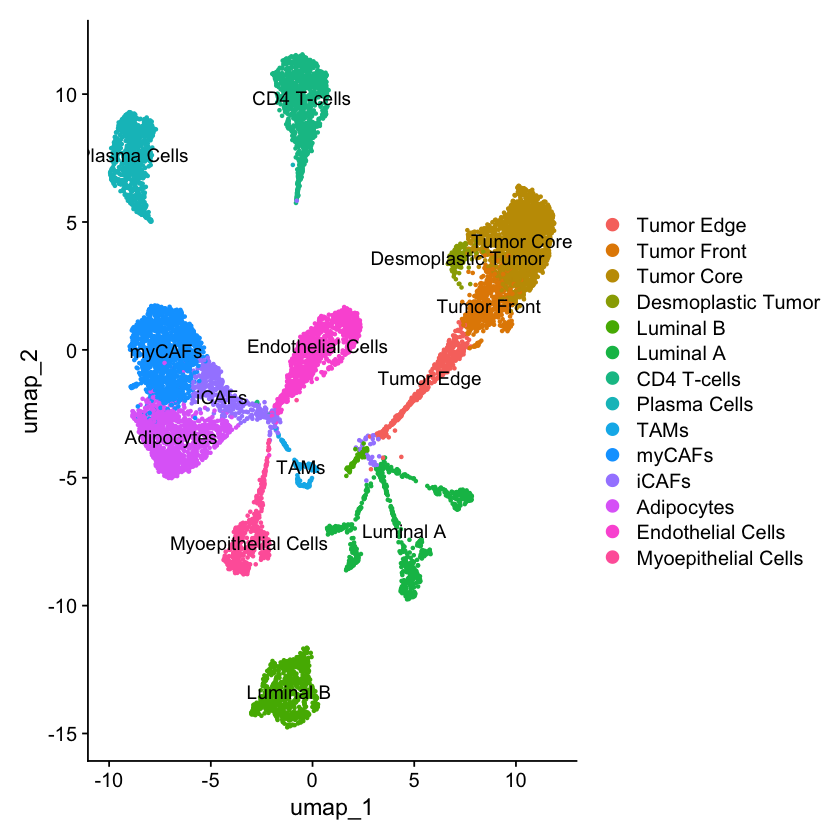

In [145]:
# UMAP Clusters 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5)

ggsave("CoDeconvClusters.jpeg", plot = last_plot(),
       width = 11, height = 10,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


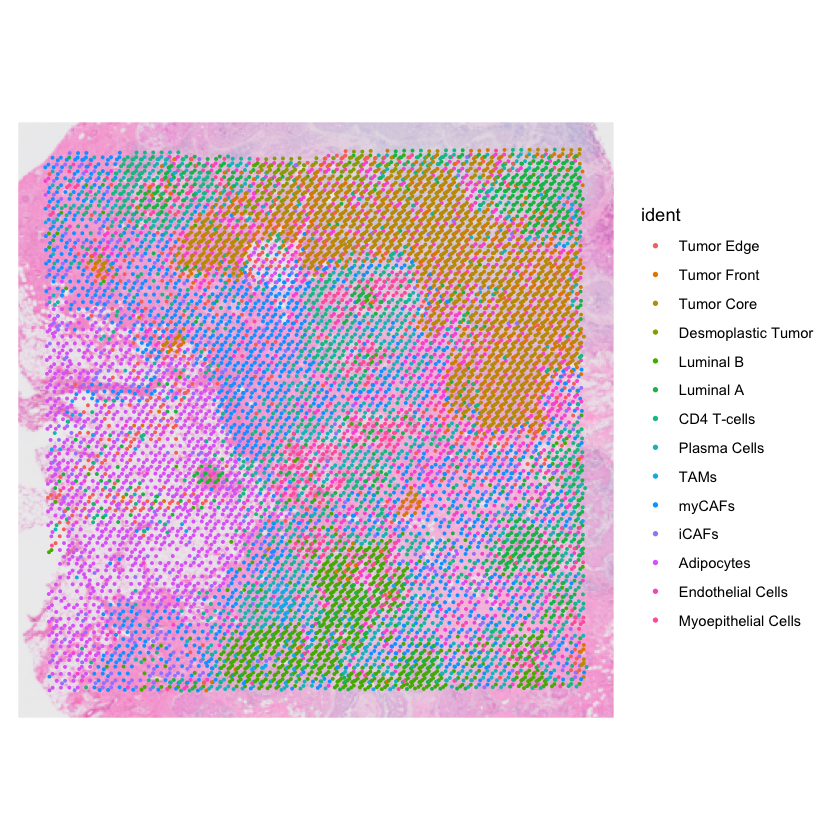

In [121]:
# Spatial Map of the Clusters
SpatialDimPlot(seurat_obj, label = FALSE, label.size = 3, pt.size.factor = 1.5)

ggsave("CoDeconvSpatialClusters.jpeg", plot = last_plot(),
       width = 12, height = 10,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


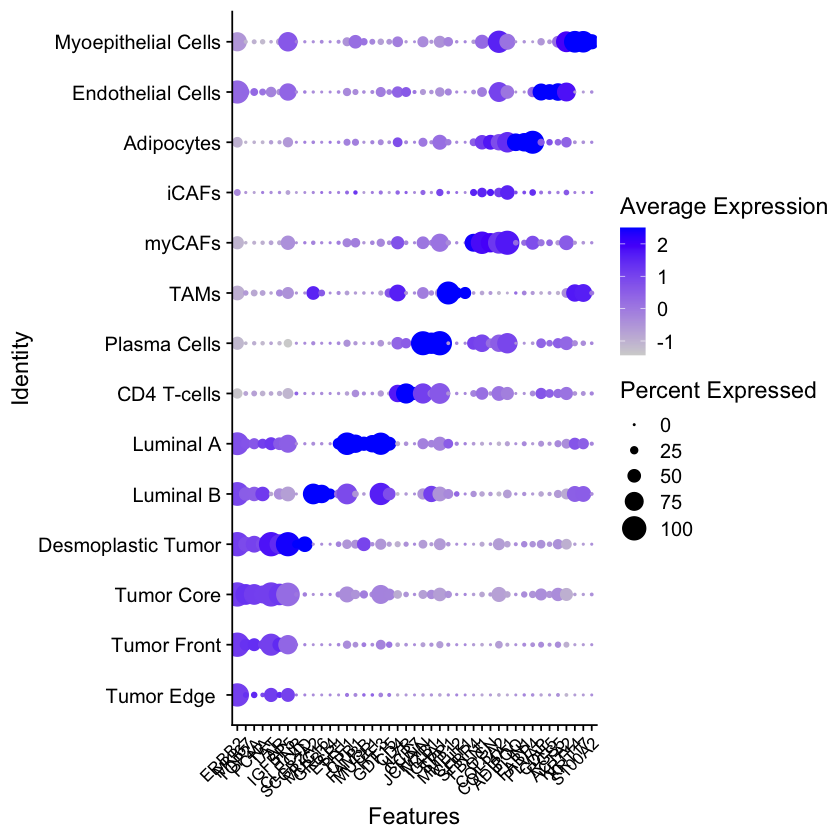

In [8]:
genes_to_plot <- c(
  "ERBB2", "MKI67", "TOP2A", 
  "PCNA", "TAT","AR",
  "IGFBP5", "TNR", "CLEC4D",  

  # LUMINAL CLONES
  "SCGB2A2", "MUC16", "GRB14",        
  "ESR1", "TFF1", "CPB1", "FAM3B",        
  "MUCL1", "TFF3", "GDF15",           

  # IMMUNE
  "CD4", "IL7R", "CCR7",              
  "JCHAIN", "MZB1", "IGHA1",         
  "SPP1", "MMP12", "CHIT1",          

  # STROMA
  "SFRP4", "FBLN1", "OGN",        
  "COL5A2", "COL14A1",              
  "ADIPOQ", "PLIN1", "FABP4", 
  "PLVAP", "CDH5", "RGS5", "ACTA2",            
  "KRT14", "KRT17", "S100A2"         
)

genes_to_plot <- unique(genes_to_plot)

# Remove any genes not found
genes_to_plot <- genes_to_plot[genes_to_plot %in% rownames(seurat_obj)]

DotPlot(
  seurat_obj,
  features = genes_to_plot,
) + 
  RotatedAxis() +                
  theme(axis.text.x = element_text(size = 10))

ggsave("CoDeconvDotPlot.jpeg", plot = last_plot(),
       width = 16, height = 6,     
       dpi = 600,                
       type = "cairo")

In [123]:
saveRDS(seurat_obj, "seurat_codeconv.rds")

# Comparison with the paired scRNA-seq data

In [146]:
Seurat <- readRDS('Seurat_Clusters.rds')

In [163]:
library(Seurat)
library(pheatmap)
library(viridis)

CompareSpatialToRef <- function(spatial_obj, ref_obj, 
                                        spatial_col = "CellType", 
                                        ref_col = "CellType",
                                        n_genes = 3500,
                                        file_prefix = "Validation_Result") { 
  
  message(paste0("1. Checking Variable Features (Target: ", n_genes, ")..."))
  
  if (length(VariableFeatures(spatial_obj)) < n_genes) {
    message("   > Recalculating Variable Features...")
    spatial_obj <- FindVariableFeatures(spatial_obj, selection.method = "vst", nfeatures = n_genes)
  }
  top_hvg <- toupper(head(VariableFeatures(spatial_obj), n_genes))
  
  message("2. Aggregating Spatial Data (Visium)...")
  sp_assay <- DefaultAssay(spatial_obj)
  spatial_list <- AverageExpression(spatial_obj, group.by = spatial_col, assays = sp_assay)
  spatial_avg <- as.matrix(spatial_list[[sp_assay]]) 
  rownames(spatial_avg) <- toupper(rownames(spatial_avg))
  
  message("3. Aggregating Reference Data (scRNA-seq)...")
  ref_assay <- DefaultAssay(ref_obj)
  ref_list <- AverageExpression(ref_obj, group.by = ref_col, assays = ref_assay)
  ref_avg <- as.matrix(ref_list[[ref_assay]]) 
  rownames(ref_avg) <- toupper(rownames(ref_avg))
  
  common_genes <- intersect(top_hvg, rownames(ref_avg))
  common_genes <- intersect(common_genes, rownames(spatial_avg))
  
  n_final <- length(common_genes)
  message(paste("   > Final Correlation calculated on", n_final, "High Variable Genes."))
  
  spatial_mtx <- spatial_avg[common_genes, ]
  ref_mtx <- ref_avg[common_genes, ]
  cor_mat <- cor(log1p(spatial_mtx), log1p(ref_mtx), method = "pearson")
  
  csv_filename <- paste0(file_prefix, ".csv")
  write.csv(cor_mat, file = csv_filename)
  message(paste("   > [SAVED] Correlation matrix saved to:", csv_filename))
  
  png_filename <- paste0(file_prefix, ".png")
  
  pheatmap(cor_mat, 
           color = viridis(100, option = "viridis"), 
           border_color = NA,
           cluster_rows = TRUE, 
           cluster_cols = TRUE, 
           fontsize_row = 9, 
           fontsize_col = 9,
           treeheight_row = 50,
           treeheight_col = 35,
           angle_col = 45,
           filename = png_filename,
           width  = 7, 
           height = 6)
           
  message(paste("   > [SAVED] High-res plot saved to:", png_filename))
           
  return(cor_mat)
}

In [164]:
correlation_matrix <- CompareSpatialToRef(
    spatial_obj = seurat_obj, 
    ref_obj = Seurat,       
    spatial_col = "CellType", 
    ref_col = "CellType",
    n_genes = 3500,
    file_prefix = "Validation"     
)

1. Checking Variable Features (Target: 3500)...

   > Recalculating Variable Features...

Finding variable features for layer counts

2. Aggregating Spatial Data (Visium)...

3. Aggregating Reference Data (scRNA-seq)...

   > Final Correlation calculated on 3500 High Variable Genes.

   > [SAVED] Correlation matrix saved to: Validation.csv

   > [SAVED] High-res plot saved to: Validation.png



In [165]:
library(ggplot2)
library(dplyr)

Analyze_Heatmap_Stats <- function(cor_matrix, filename = "Annotation_Confidence_500dpi.png") {
  
  df_stats <- data.frame(
    Visium_Cluster = rownames(cor_matrix),
    Best_Match_Ref = colnames(cor_matrix)[apply(cor_matrix, 1, which.max)],
    Correlation = apply(cor_matrix, 1, max) 
  )
  
  df_stats <- df_stats %>% arrange(desc(Correlation))
  
  mean_corr <- mean(df_stats$Correlation)
  
  message(paste("STATS"))
  message(paste("Mean Best-Match Correlation:", round(mean_corr, 4)))
  
  p <- ggplot(df_stats, aes(x = reorder(Visium_Cluster, Correlation), y = Correlation)) +
    geom_col(aes(fill = Correlation), width = 0.7) + 
    
    geom_text(aes(label = Best_Match_Ref), 
              hjust = -0.1,  
              size = 4) +
    
    coord_flip(clip = "off") +
    
    scale_fill_viridis_c(option = "plasma", limits = c(0, 1), direction = 1) +
    
    labs(title = "Validation of Spatial Clusters",
         subtitle = paste0("Mean Pearson Correlation with the Single-Cell Reference: R = ", round(mean_corr, 4)),
         y = "Pearson Correlation (Best Match)",
         x = "") + 
    
    theme_classic(base_size = 14) +
    theme(
      plot.margin = margin(t=10, r=70, b=10, l=10), 
      legend.position = "none",
      axis.text.y = element_text(color = "black")
    )
  
  message(paste("Saving to:", filename, "..."))
  
  ggsave(filename = filename, 
         plot = p, 
         width = 12,  
         height = 8, 
         dpi = 500)  
  
  print(p)
  return(df_stats)
}

STATS

Mean Best-Match Correlation: 0.6852

Saving to: Validation_Barplot.png ...



                         Visium_Cluster Best_Match_Ref Correlation
Tumor Core                   Tumor Core Dividing Tumor   0.8289243
Tumor Front                 Tumor Front Dividing Tumor   0.8231512
Luminal A                     Luminal A      Luminal A   0.8163135
Desmoplastic Tumor   Desmoplastic Tumor Dividing Tumor   0.8013165
Tumor Edge                  Tumor Edge  Dividing Tumor   0.7975625
Luminal B                     Luminal B      Luminal B   0.7119690
myCAFs                           myCAFs    Fibroblasts   0.7030314
Adipocytes                   Adipocytes    Fibroblasts   0.6829439
iCAFs                             iCAFs    Fibroblasts   0.6583474
Endothelial Cells     Endothelial Cells    Fibroblasts   0.5941801
TAMs                               TAMs           TAMs   0.5663496
Myoepithelial Cells Myoepithelial Cells    Fibroblasts   0.5629864
CD4 T-cells                 CD4 T-cells    CD4 T-Cells   0.5278403
Plasma Cells               Plasma Cells   Plasma Cells   0.517

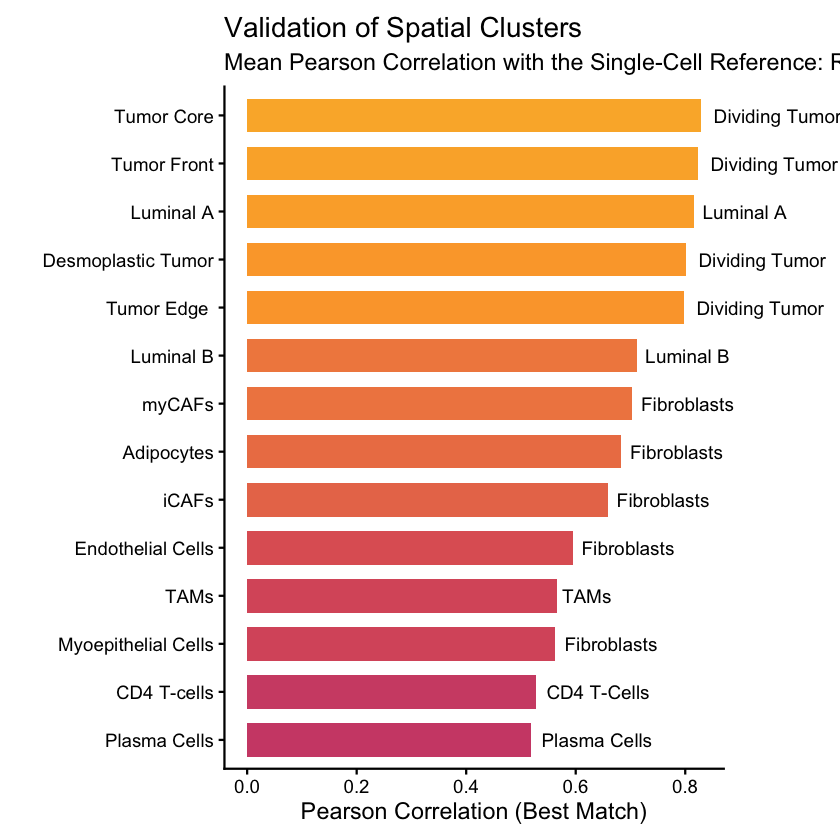

In [166]:
if(file.exists("Validation.csv")) {
  cor_matrix <- read.csv("Validation.csv", row.names = 1, 
                       check.names = FALSE)
} else {
  stop("File not found.")
}

stats_df <- Analyze_Heatmap_Stats(cor_matrix, filename = "Validation_Barplot.png")

print(stats_df)